In [52]:
# Libreria para extraer comentarios de Youtube
!pip install youtube-comment-downloader
# Descargar modelo español de spaCy
!python -m spacy download es_core_news_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/es_core_news_sm-3.8.0/es_core_news_sm-3.8.0-py3-none-any.whl (12.9 MB)
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Obtenemos comentarios de un video de youtube:

In [53]:
import pandas as pd
from itertools import islice
from youtube_comment_downloader import *

downloader = YoutubeCommentDownloader()
video_url = "https://www.youtube.com/watch?v=c0cUE-ePDEc" # Cambia por el link del video de interés
comments = downloader.get_comments_from_url(video_url, sort_by=SORT_BY_POPULAR)
list_comments = list(comments)

In [54]:
df = pd.DataFrame(list_comments)
df

,cid,text,time,author,channel,votes,replies,photo,heart,reply,time_parsed
0,Ugyg0XuUDnq9NQOzPlF4AaABAg,Enjoy the full FIFA World Cup archive for FREE...,3 years ago,@fifa,UCpcTrCXblq78GZrTUTLWeBw,996,39,https://yt3.ggpht.com/9UB1blxIJIz-OQmtHTsGEvYn...,False,False,1.669045e+09
1,UgxWy6kVviqbY3ED-jt4AaABAg,2014 was 10 times better than 2018,6 years ago,@ahmedal-zamzami3456,UCtgqWU1Ysbcnt0GrZdrpluQ,9.9K,226,https://yt3.ggpht.com/ytc/AIdro_lxI-DdiyyJaXHz...,False,False,1.574350e+09
2,UgydEH8RyRo5PZUmaA14AaABAg,I remember this world cup for 2 reasons \n1. J...,5 years ago,@mrweird14,UCJadfjbdyd33K0kjMwtzUlQ,19K,212,https://yt3.ggpht.com/N8youZ_PyeM8k_XTe9SI8PuM...,False,False,1.605973e+09
3,Ugw8EbL65scjQeMapud4AaABAg,"Feels like yesterday!! Brazil 2014, what a wo...",6 years ago,@AdityaSingh-tj6mf,UCVisdfFeCZNfnU1atXzhDvg,7.8K,40,https://yt3.ggpht.com/ytc/AIdro_kqQWlp1BiIykD3...,False,False,1.574350e+09
4,Ugzai2r8uij0bB1mV0t4AaABAg,There was definitely something special about t...,5 years ago,@yeahwhatever3576,UCmTQf7zV0TiEy81R_A_ifow,15K,176,https://yt3.ggpht.com/ytc/AIdro_nuC16_WSVoLY1Z...,False,False,1.605973e+09
...,...,...,...,...,...,...,...,...,...,...,...
5612,UgwZt_o74RsJbTdGmft4AaABAg,Na qatar 2022 😂,10 months ago,@elielgomez7921,UCZxSssXLzKzFyEdqV6Wyttw,0,,https://yt3.ggpht.com/L7ohp4lJihvlFP5ggmk4kvIR...,False,False,1.737474e+09
5613,Ugx_VuoWqz1tF8pEw8B4AaABAg,2025 🇺🇿🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥😄,10 months ago,@Shoxrux_choriyev,UCeYqCOpcZXhrgz28L58PECA,0,,https://yt3.ggpht.com/ifts4MPfiJ7QY5UR2cBPmrjX...,False,False,1.737474e+09
5614,UgyhYlBQQ_cpZyA3yWx4AaABAg,Quiten el 3 de james y pongan el de Giovanni d...,2 years ago,@len2336,UC80YhBc77MZUObpccs5acQQ,0,,https://yt3.ggpht.com/gn9SFra7zV1teVCxpaT75qgL...,False,False,1.700581e+09
5615,UgwlLajCprbVyfRfVVZ4AaABAg,Donde esta penaldo? 😹🐫🇵🇹,1 year ago,@xxmarcos_09xx,UCN9VfcUTijv-CqZNXVii2yA,0,,https://yt3.ggpht.com/Lp8cSpjx8btxEV2DJV-4_96O...,False,False,1.732203e+09


In [55]:
count = 10
for _, comment in df.iterrows():
    if count == 0:
        break
    count -= 1
    print(comment[1])
    print('--------')


Enjoy the full FIFA World Cup archive for FREE on FIFA+ 👉 https://fifa.fans/3cm7uwn
--------
2014 was 10 times better than 2018
--------
I remember this world cup for 2 reasons 
1. James Rodriquez 
2. Germany 7-1 Brazil
--------
Feels like yesterday!!  Brazil 2014, what a world Cup!!
--------
There was definitely something special about this World Cup
--------
JAMES RODRIGUEZ IS MVP OF WORLD CUP 2014... sad to see colombia not even in 2022 world cup 🥲
--------
I remember this world cup for 5 reasons
1. Messi looking at the World Cup trophy
2. James Rodriguez's wonder goal
3. Germany 7-1 Brazil
4. Neymar's injury
5. The flying Dutchman - Robin Van Persie
--------
The amount of emotion in each and every single goal is what makes the World Cup the best sporting event of all time
--------
Don’t care what anyone says, THIS is what a World Cup is meant to be, I remember this World Cup like it was yesterday, this World Cup made me so happy, angry, sad, it gave me all kinds of emotions that no

/tmp/ipython-input-3081484658.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(comment[1])


In [69]:
import nltk
import spacy
import re
nltk.download('stopwords')
from nltk.corpus import stopwords

# nlp para comentarios en español
nlp = spacy.load("es_core_news_sm")
# nlp para comentarios en ingles
nlp_en = spacy.load("en_core_web_sm")

# Preprocesar
# StopWords en español
stopwords_es = set(stopwords.words('spanish'))
# StopWords en ingles
stopwords_en = set(stopwords.words('english'))

def preprocess(text):
    # Convertir texto a minuscula
    text = str(text).lower()
    # Remover URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remover caracteres especiales
    text = re.sub(r'[^\w\s\d]', '', text)
    doc = nlp_en(text)
    tokens = [token.lemma_ for token in doc if token.is_alpha and token.text not in stopwords_en]
    return " ".join(tokens)

df['comentario_limpio'] = df['text'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [70]:
df[['text','comentario_limpio']].head(10)

,text,comentario_limpio
0,Enjoy the full FIFA World Cup archive for FREE...,enjoy full fifa world cup archive free fifa
1,2014 was 10 times better than 2018,time well
2,I remember this world cup for 2 reasons \n1. J...,remember world cup reason jame rodriquez germa...
3,"Feels like yesterday!! Brazil 2014, what a wo...",feel like yesterday brazil world cup
4,There was definitely something special about t...,definitely something special world cup
5,JAMES RODRIGUEZ IS MVP OF WORLD CUP 2014... sa...,james rodriguez mvp world cup sad see colombia...
6,I remember this world cup for 5 reasons\n1. Me...,remember world cup reason messi look world cup...
7,The amount of emotion in each and every single...,amount emotion every single goal make world cu...
8,"Don’t care what anyone says, THIS is what a Wo...",not care anyone say world cup mean remember wo...
9,2014 World Cup was special. Coming from a Braz...,world cup special come brazil fan forever reme...


## Analisis sencillo, segmentación básica

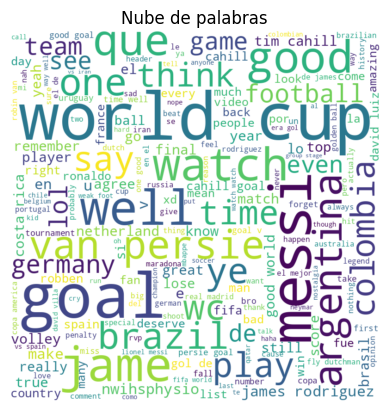

In [58]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## Obtiene el conteo de palabras y muestra las más repetidas (más relevantes) en un tamaño de fuente mucho mayor

text = " ".join(df['comentario_limpio'])
wordcloud = WordCloud(width=800, height=800, background_color='white').generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.title(f"Nube de palabras")
plt.axis("off")
plt.show()


## Aplicando análisis de sentimientos

In [59]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [60]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Analizador de sentimientos
sid = SentimentIntensityAnalyzer()

# Definir una funcion para asignar el sentimiento a cada comentario
def get_sentiment(text):
    scores = sid.polarity_scores(text)
    compound_score = scores['compound']
    if compound_score > 0.05:
        return 'Positive'
    elif compound_score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Aplicar la funcion de sentimiento a los comentarios
df['sentimiento'] = df['comentario_limpio'].apply(get_sentiment)

In [61]:
df[['text','sentimiento']]

,text,sentimiento
0,Enjoy the full FIFA World Cup archive for FREE...,Positive
1,2014 was 10 times better than 2018,Positive
2,I remember this world cup for 2 reasons \n1. J...,Neutral
3,"Feels like yesterday!! Brazil 2014, what a wo...",Positive
4,There was definitely something special about t...,Positive
...,...,...
5612,Na qatar 2022 😂,Neutral
5613,2025 🇺🇿🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥😄,Neutral
5614,Quiten el 3 de james y pongan el de Giovanni d...,Neutral
5615,Donde esta penaldo? 😹🐫🇵🇹,Neutral


## Aplicando vectorización a los datos

Usar un vectorizador para convertir los comentarios de texto a una representacion numerica

In [62]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectoriza el texto dando relevancia a las palabras no tan comunes, las cuales proveen mayor cercanía al contexto de la situación
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['comentario_limpio'])

## Segmentación por temáticas internas en el texto con LDA

In [63]:
from sklearn.decomposition import LatentDirichletAllocation

# Determinar un número apropiado de tematicas a analizar
n_topics = 5

# Usar un modelo de LatentDirichletAllocation
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X)

# Obtener la distribución de los temas para cada comentario
topic_distribution = lda.transform(X)

# Asignar el tema dominante a cada comentario
df['tema_dominante'] = topic_distribution.argmax(axis=1)

topic_distribution

array([[0.0573067 , 0.0582829 , 0.29736521, 0.52922666, 0.05781853],
       [0.6665056 , 0.08359682, 0.08340531, 0.08342299, 0.08306927],
       [0.48912971, 0.34559027, 0.05435409, 0.05614498, 0.05478095],
       ...,
       [0.05593254, 0.05583975, 0.05614875, 0.77623312, 0.05584585],
       [0.07382243, 0.07366719, 0.70032096, 0.07885208, 0.07333735],
       [0.2       , 0.2       , 0.2       , 0.2       , 0.2       ]])

In [64]:
df.head()

,cid,text,time,author,channel,votes,replies,photo,heart,reply,time_parsed,comentario_limpio,sentimiento,tema_dominante
0,Ugyg0XuUDnq9NQOzPlF4AaABAg,Enjoy the full FIFA World Cup archive for FREE...,3 years ago,@fifa,UCpcTrCXblq78GZrTUTLWeBw,996,39,https://yt3.ggpht.com/9UB1blxIJIz-OQmtHTsGEvYn...,False,False,1.669045e+09,enjoy full fifa world cup archive free fifa,Positive,3
1,UgxWy6kVviqbY3ED-jt4AaABAg,2014 was 10 times better than 2018,6 years ago,@ahmedal-zamzami3456,UCtgqWU1Ysbcnt0GrZdrpluQ,9.9K,226,https://yt3.ggpht.com/ytc/AIdro_lxI-DdiyyJaXHz...,False,False,1.574350e+09,time well,Positive,0
2,UgydEH8RyRo5PZUmaA14AaABAg,I remember this world cup for 2 reasons \n1. J...,5 years ago,@mrweird14,UCJadfjbdyd33K0kjMwtzUlQ,19K,212,https://yt3.ggpht.com/N8youZ_PyeM8k_XTe9SI8PuM...,False,False,1.605973e+09,remember world cup reason jame rodriquez germa...,Neutral,0
3,Ugw8EbL65scjQeMapud4AaABAg,"Feels like yesterday!! Brazil 2014, what a wo...",6 years ago,@AdityaSingh-tj6mf,UCVisdfFeCZNfnU1atXzhDvg,7.8K,40,https://yt3.ggpht.com/ytc/AIdro_kqQWlp1BiIykD3...,False,False,1.574350e+09,feel like yesterday brazil world cup,Positive,2
4,Ugzai2r8uij0bB1mV0t4AaABAg,There was definitely something special about t...,5 years ago,@yeahwhatever3576,UCmTQf7zV0TiEy81R_A_ifow,15K,176,https://yt3.ggpht.com/ytc/AIdro_nuC16_WSVoLY1Z...,False,False,1.605973e+09,definitely something special world cup,Positive,3


In [65]:
# Indentificar las palabras clave para cada uno de los temas
feature_names = vectorizer.get_feature_names_out()
topic_words = []
for topic_idx, topic in enumerate(lda.components_):
    top_words_indices = topic.argsort()[:-5 - 1:-1]
    top_words = [feature_names[i] for i in top_words_indices]
    print(f"Topic {topic_idx}: {', '.join(top_words)}")
    topic_words.append(', '.join(top_words))

df_topic_words = pd.DataFrame(topic_words, columns=['palabras clave'])
df_topic_words.head()

Topic 0: well, lol, vs, time, messi
Topic 1: van, persie, goal, agree, well
Topic 2: goal, cahill, james, tim, not
Topic 3: cup, world, good, de, el
Topic 4: watch, yes, true, messi, brazil


,palabras clave
0,"well, lol, vs, time, messi"
1,"van, persie, goal, agree, well"
2,"goal, cahill, james, tim, not"
3,"cup, world, good, de, el"
4,"watch, yes, true, messi, brazil"


## Segmentacion de clientes



In [66]:
customer_segments = df.groupby(['tema_dominante', 'sentimiento']).size().reset_index(name='comment_count')
display(customer_segments)

,tema_dominante,sentimiento,comment_count
0,0,Negative,89
1,0,Neutral,1129
2,0,Positive,436
3,1,Negative,118
4,1,Neutral,498
5,1,Positive,329
6,2,Negative,109
7,2,Neutral,472
8,2,Positive,338
9,3,Negative,125


## Caracterizacion de cada segmento de clientes


In [67]:
df_topic_words

,palabras clave
0,"well, lol, vs, time, messi"
1,"van, persie, goal, agree, well"
2,"goal, cahill, james, tim, not"
3,"cup, world, good, de, el"
4,"watch, yes, true, messi, brazil"


In [68]:
segment_0_sentiment = customer_segments[customer_segments['tema_dominante'] == 0]
print("Segmento 0:")
display(segment_0_sentiment.sort_values(by='comment_count', ascending=False))
display(df_topic_words.iloc[0])

segment_1_sentiment = customer_segments[customer_segments['tema_dominante'] == 1]
print("Segmento 1:")
display(segment_1_sentiment.sort_values(by='comment_count', ascending=False))
display(df_topic_words.iloc[1])

segment_2_sentiment = customer_segments[customer_segments['tema_dominante'] == 2]
print("Segmento 2:")
display(segment_2_sentiment.sort_values(by='comment_count', ascending=False))
display(df_topic_words.iloc[2])

segment_3_sentiment = customer_segments[customer_segments['tema_dominante'] == 3]
print("Segmento 3:")
display(segment_3_sentiment.sort_values(by='comment_count', ascending=False))
display(df_topic_words.iloc[3])

segment_4_sentiment = customer_segments[customer_segments['tema_dominante'] == 4]
print("Segmento 4:")
display(segment_4_sentiment.sort_values(by='comment_count', ascending=False))
display(df_topic_words.iloc[4])

Segmento 0:


,tema_dominante,sentimiento,comment_count
1,0,Neutral,1129
2,0,Positive,436
0,0,Negative,89


,0
palabras clave,"well, lol, vs, time, messi"


Segmento 1:


,tema_dominante,sentimiento,comment_count
4,1,Neutral,498
5,1,Positive,329
3,1,Negative,118


...

,tema_dominante,sentimiento,comment_count
10,3,Neutral,709
11,3,Positive,401
9,3,Negative,125


,3
palabras clave,"cup, world, good, de, el"


Segmento 4:


,tema_dominante,sentimiento,comment_count
13,4,Neutral,544
14,4,Positive,261
12,4,Negative,59


,4
palabras clave,"watch, yes, true, messi, brazil"
